In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
# Load Data
df = pd.read_csv('data/cleaned_data.csv')

### Remove outliers in SQM

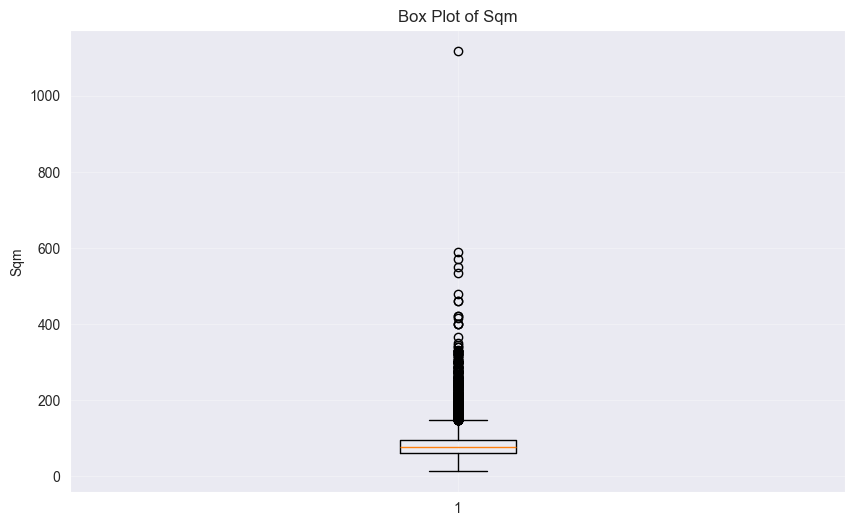

In [22]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['Sqm'])
plt.title('Box Plot of Sqm')
plt.ylabel('Sqm')
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
print("DF shape before removing outliers:", df.shape)
Q1 = df['Sqm'].quantile(0.25)
Q3 = df['Sqm'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Sqm'] >= lower_bound) & (df['Sqm'] <= upper_bound)]
print("DF shape after removing outliers:", df.shape)

DF shape before removing outliers: (19235, 13)
DF shape after removing outliers: (18411, 13)


### Process Price column

In [24]:
df['Price']=df['Price'].astype(float)
df=df[df.Currency!="Na"]

In [25]:
df['Currency'].unique()

array(['$', '֏', nan, '₽'], dtype=object)

In [26]:
with open('data/rates.json', 'r') as f:
    rates = json.load(f)

In [27]:
# converting all prices to USD
df['Price_USD']=np.nan
df['Price_USD']=np.where(df.Currency=='֏', round(df.Price/rates["AMD"], 0), df['Price_USD'])
df['Price_USD']=np.where(df.Currency=='₽', round(df.Price*rates["RUR"], 0), df['Price_USD'])
df['Price_USD']=np.where(df.Currency=='$', df.Price, df['Price_USD'])

df["Price_USD"]=pd.to_numeric(df["Price_USD"])
df=df.dropna(subset=['Price_USD'])


In [28]:
df.drop(['Price', 'Currency'], axis=1, inplace=True)

### Convert categorical columns to numerical

In [29]:
print(df['Type'].unique())
df['Type'] = np.where(df['Type'] == 'Փայտե', 'Այլ',df['Type'])
df['Type'] = np.where(df['Type'] == 'Աղյուսե', 'Այլ',df['Type'])
df['Type'] = np.where(df['Type'] == 'Կասետային', 'Այլ',df['Type'])

df['Type'] = df['Type'].map({'Քարե': 0, 'Պանելային': 1, 'Մոնոլիտ': 2, 'Այլ': 3})

['Պանելային' 'Մոնոլիտ' 'Քարե' 'Կասետային' 'Աղյուսե' 'Փայտե']


In [30]:
print(df['New_building'].unique())
df['New_building'] = df['New_building'].map({'Ոչ': 0, 'Այո': 1})


['Ոչ' 'Այո']


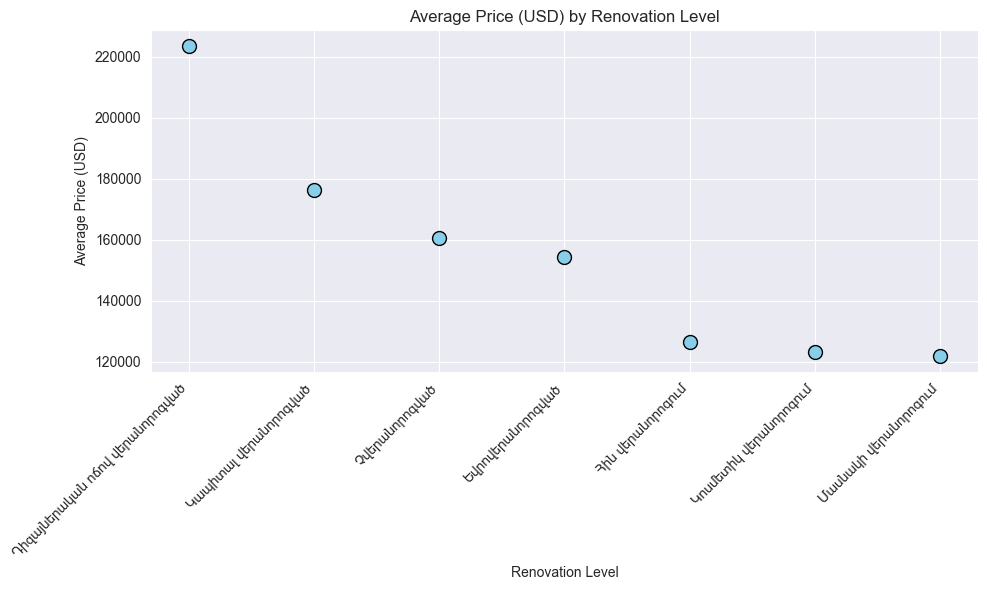

In [31]:
# Create a scatter plot showing average price by Renovation level
renovation_price = df.groupby('Renovation')['Price_USD'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.scatter(range(len(renovation_price)), renovation_price.values, color='skyblue', edgecolor='black', s=100)
plt.xticks(range(len(renovation_price)), renovation_price.index, rotation=45, ha='right')

plt.title('Average Price (USD) by Renovation Level')
plt.xlabel('Renovation Level')
plt.ylabel('Average Price (USD)')
plt.tight_layout()
plt.show()

In [32]:
# Create a ranking dictionary for renovation types
renovation_ranking = {
    'Չվերանորոգված': 0,
    'Հին վերանորոգում': 0.5,
    'Մասնակի վերանորոգում': 1,
    'Կոսմետիկ վերանորոգում': 1.5,
    'Կապիտալ վերանորոգված': 2,
    'Եվրովերանորոգված': 3,
    'Դիզայներական ոճով վերանորոգված': 4
}
df['Renovation'] = df['Renovation'].map(renovation_ranking)


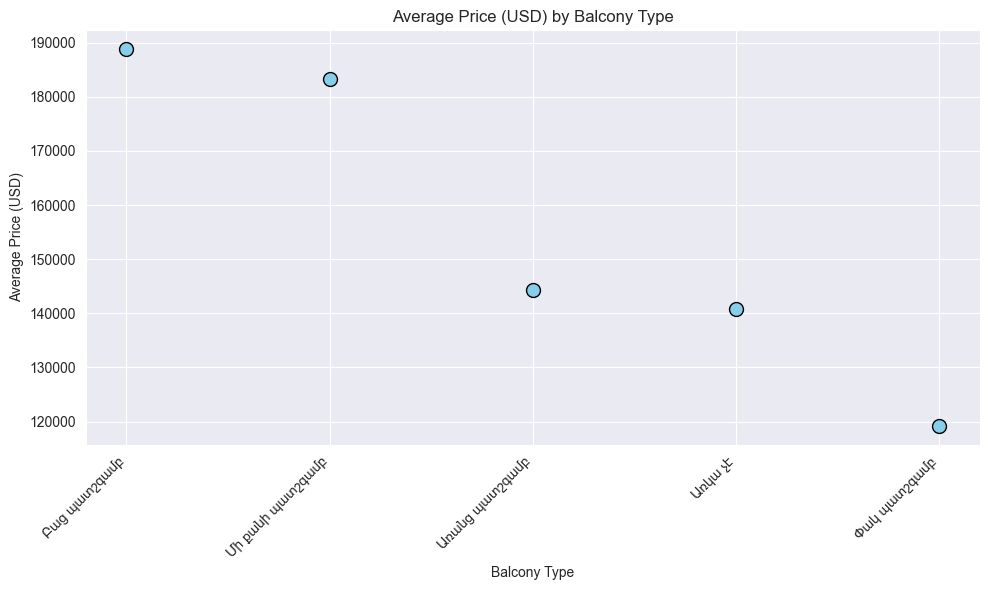

In [33]:
# Create a bar plot showing average price by balcony type
balcony_price = df.groupby('Balcony')['Price_USD'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.scatter(range(len(balcony_price)), balcony_price.values, color='skyblue', edgecolor='black', s=100)
plt.xticks(range(len(balcony_price)), balcony_price.index, rotation=45, ha='right')

plt.title('Average Price (USD) by Balcony Type')
plt.xlabel('Balcony Type')
plt.ylabel('Average Price (USD)')
plt.tight_layout()
plt.show()

In [34]:
# Balcony type ranking based on average price
balcony_ranking = {
    'Փակ պատշգամբ': 0, 
    'Առկա չէ': 1, 
    'Առանց պատշգամբ': 1,
    'Բաց պատշգամբ': 2, 
    'Մի քանի պատշգամբ': 3
}
df['Balcony'] = df['Balcony'].map(balcony_ranking)

In [35]:
df.head()

,Type,New_building,nFloor,Floor,Height,Sqm,Rooms,Bathrooms,Renovation,Balcony,District,Price_USD
0,1,0,9,6,2.80,68,2,1,2.0,0,Մալաթիա-Սեբաստիա,95000.0
1,2,1,12,6,3.00,46,2,1,2.0,2,Աջափնյակ,87000.0
2,0,0,4,2,3.00,50,1,1,1.0,0,Կենտրոն,130000.0
3,0,0,5,1,2.75,70,3,1,2.0,3,Արաբկիր,145000.0
4,2,1,8,5,3.00,47,2,1,2.0,2,Արաբկիր,160000.0


In [36]:
df.shape

(18374, 12)

In [37]:
pd.DataFrame(df).to_csv("data/processed_data.csv", index=False)